<!-- civilpy-title-block -->
<div style="border-top:6px solid #0E3F75; border-bottom:2px solid #C12637; padding:0.6em 0 0.6em 0; margin-bottom:1.2em;">
<span style="font-size:1.5em; font-weight:bold; color:#0E3F75;">6. Site Terrain and Alignment</span><br>
<span style="color:#54585A;">Ohio Department of Transportation &middot; CivilPy Notebook Series</span>
</div>

# Site Terrain & Alignment — real Ohio LiDAR to a designed alignment

**The site-development leg of the bridge pipeline, in native civilpy.** In
production this work usually happens in **MicroStation / OpenRoads** — the
bridge notebooks only consume its results (a crossing length, endpoint
elevations, a grade). This notebook is the civilpy-native alternative for
quick studies: pick a site on a map, pull the real OGRIP/3DEP LiDAR, build
a queryable terrain, and establish a designed alignment over it.

The pieces:

1. **Pick the site** — draw a rectangle on the map; `picker.bbox` holds the
   WGS84 corners live.
2. **Fetch the LiDAR** — `Terrain.from_ogrip(bbox)` queries the live
   `OGRIP/3DepTiles` index, downloads the ZIP tiles, extracts the LAS, and
   builds a TIN with barycentric `elevation_at` lookup.
3. **Establish an alignment** — two points + optional curvature; the
   profile grade is a design decision (`start_elev_ft` / `end_elev_ft`) or,
   when the frames are tied together, sampled from the terrain.

> Each LiDAR tile is a **50–120 MB ZIP** — keep the rectangle tight around
> the crossing. Tiles cache in `temp_las/` so reruns skip the download.
> The LiDAR arrives in **Ohio State Plane feet** (EPSG:3754, x ≈ 1.8M ft).

## 1. Pick the site on the map

Hybrid satellite view; use the search box (top left) to fly to an address
or place, then the rectangle tool to drag a box over the crossing. The
readout in the corner shows the live bbox — `(west_lon, south_lat,
east_lon, north_lat)` in decimal degrees, exactly the tuple
`Terrain.from_ogrip` takes.

> Needs `ipyleaflet` in the environment that launches JupyterLab (its
> `jupyter-leaflet` JS half is served by Lab, not the kernel), then a full
> server restart: `pip install ipyleaflet jupyter-leaflet`.

In [2]:
from civilpy.transportation.terrain import bbox_picker

picker = bbox_picker(center=(40.004, -83.005), zoom=15)
picker

Map(center=[40.004, -83.005], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

## 2. Fetch the real LiDAR terrain

`from_ogrip` finds every OSIP/3DEP flight tile intersecting the bbox,
keeps the newest collection year where flights overlap, downloads and
extracts, and triangulates the ground returns. With no rectangle drawn the
single-tile demo bbox below is used (~120 MB on first run, cached after).

In [3]:
from civilpy.transportation.terrain import Terrain

# a point-sized demo bbox near Columbus -- intersects exactly one tile
bbox_wgs84 = (picker.bbox if picker.bbox
              else (-83.0050, 40.0020, -83.0049, 40.0021))
print(f"bbox (W, S, E, N): {bbox_wgs84}")

terrain = Terrain.from_ogrip(bbox_wgs84, thin=25)   # cached in temp_las/

x0, y0, x1, y1 = terrain.bounds
zc = terrain.elevation_at((x0 + x1) / 2.0, (y0 + y1) / 2.0)
print(f"points          : {terrain.n_points:,} (ground returns, thinned)")
print(f"extent (ft)     : {x1 - x0:,.0f} x {y1 - y0:,.0f}  "
      f"(Ohio State Plane, x {x0:,.0f}..{x1:,.0f})")
print(f"elev range (ft) : {terrain.points[:, 2].min():.1f} .. "
      f"{terrain.points[:, 2].max():.1f}")
print(f"elev at center  : {zc:.1f}" if zc is not None else
      "elev at center  : n/a (outside TIN)")

bbox (W, S, E, N): (-83.023564, 40.006035, -83.020876, 40.006959)
points          : 254,751 (ground returns, thinned)
extent (ft)     : 2,500 x 2,500  (Ohio State Plane, x 1,821,250..1,823,750)
elev range (ft) : 717.5 .. 748.9
elev at center  : 738.9


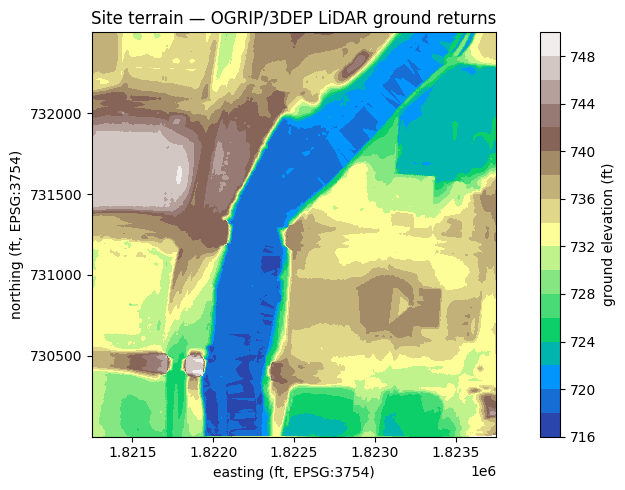

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
tri = ax.tricontourf(terrain.points[:, 0], terrain.points[:, 1],
                     terrain.points[:, 2], levels=18, cmap="terrain")
fig.colorbar(tri, ax=ax, label="ground elevation (ft)")
ax.set_xlabel("easting (ft, EPSG:3754)")
ax.set_ylabel("northing (ft, EPSG:3754)")
ax.set_title("Site terrain — OGRIP/3DEP LiDAR ground returns")
ax.set_aspect("equal"); plt.tight_layout(); plt.show()

## 3. Establish an alignment

An alignment is a *designed* geometry — you can't drape it on a TIN. The
conceptual-design move is **two points and a curvature**:
`Alignment.between_points` back-computes bearing, length, and (for a
curve) the deflection from the chord. The profile comes from designed
endpoint elevations, or — when the alignment is laid out in the terrain's
state-plane frame — from `terrain=`, which samples the ground at each end.

Here the alignment crosses the fetched tile so the ground profile is real:
the endpoints sit inside the terrain extent, and the roadway grade is set
by design elevations a few feet above grade at each end.

In [5]:
import numpy as np
from civilpy.transportation.alignment import Alignment

# lay the crossing out IN THE TERRAIN FRAME (state plane ft), through the
# middle of the fetched tile
cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
p0 = (cx - 345.0, cy)
p1 = (cx + 345.0, cy)
z0g, z1g = terrain.elevation_at(*p0), terrain.elevation_at(*p1)
print(f"ground at endpoints: {z0g:.1f} ft -> {z1g:.1f} ft")

al = Alignment.between_points(p0, p1, start_station_ft=1000.0,
                              start_elev_ft=z0g + 4.0,  # designed profile:
                              end_elev_ft=z1g + 4.0)    # ~4 ft above grade
grade = ((al.elevation_at(al.end_station) - al.elevation_at(al.start_station))
         / al.length_ft * 100.0)
print(f"length : {al.length_ft:.1f} ft   "
      f"bearing {al.bearing_at(al.start_station):.1f} deg   "
      f"grade {grade:+.2f}%")

# curved alternative: same two points joined by one arc
al_curved = Alignment.between_points(p0, p1, radius_ft=2500.0, direction="R")
print(f"curved option: R=2500 ft -> arc length {al_curved.length_ft:.1f} ft")

ground at endpoints: 718.5 ft -> 733.9 ft
length : 690.0 ft   bearing 90.0 deg   grade +2.23%
curved option: R=2500 ft -> arc length 692.2 ft


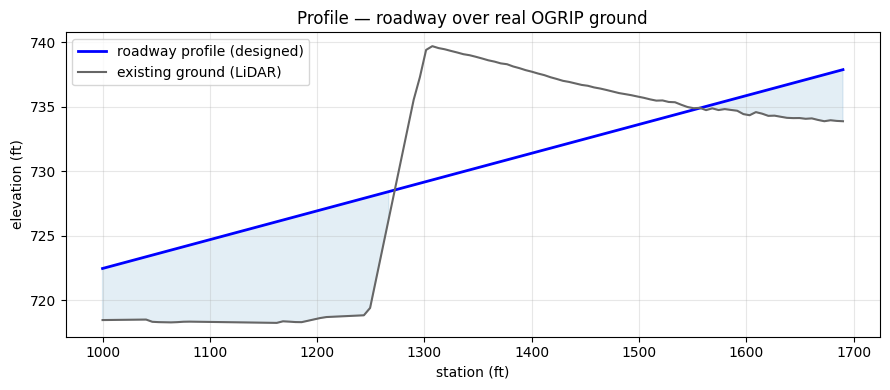

In [6]:
# Roadway profile vs. real ground along the alignment
stations = np.linspace(al.start_station, al.end_station, 120)
road_z = np.array([al.elevation_at(s) for s in stations])
grnd_z = np.array([terrain.elevation_along(al, s, 0.0) for s in stations],
                  dtype=float)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(stations, road_z, "b-", lw=2, label="roadway profile (designed)")
ax.plot(stations, grnd_z, color="0.4", lw=1.5, label="existing ground (LiDAR)")
ax.fill_between(stations, grnd_z, road_z, where=road_z > grnd_z,
                color="tab:blue", alpha=0.12)
ax.set_xlabel("station (ft)"); ax.set_ylabel("elevation (ft)")
ax.set_title("Profile — roadway over real OGRIP ground")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---

## What the bridge notebooks take from here

The bridge walkthroughs (*Steel Girder Bridge Walkthrough*, *Box Beam
Bridge Walkthrough*, *Substructure Gallery*) are **pure bridge-creation
exercises** — they start from the numbers this study (or OpenRoads)
produces:

- **crossing length** between the abutments → the span arrangement,
- **endpoint elevations / grade** → the designed profile,
- **ground line under the crossing** → pier heights and wingwall sizing.

Everything downstream — type feasibility, layout, MIDAS grillage,
construction staging, substructure design, and the tagged Rhino BrIM
model — lives in those notebooks and never touches the terrain machinery.